In [ ]:
try:
    import torch_geometric
except ImportError:
    print("Installing torch_geometric...")
    !pip install torch_geometric

import torch
from torch_geometric.data import Data

Installing torch_geometric...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.4 MB/s eta 0:00:00


In [ ]:
try:
    import igraph
except ImportError:
    print("Installing igraph...")
    !pip install igraph


from igraph import Graph

Installing igraph...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.3 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, LabelPropagation, SAGEConv
import matplotlib.pyplot as plt
import numpy as np
import gc
from torch_geometric.loader import NeighborLoader
import time
from sklearn.preprocessing import LabelEncoder

###**BUILDING GRAPH**

In [ ]:
GRAPH_PATH = "/content/drive/MyDrive/I -TEAM FILES/Datasets/Comment_Struc (Features) - Graph.graphml"

In [ ]:
g = Graph.Read_GraphML(GRAPH_PATH)
print(f"Loaded graph with {g.vcount()} nodes and {g.ecount()} edges")

<ipython-input-5-b43947c0972a>:1: RuntimeWarning: Could not add vertex ids, there is already an 'id' vertex attribute. at src/io/graphml.c:488
  g = Graph.Read_GraphML(GRAPH_PATH)


Loaded graph with 325320 nodes and 6112052 edges


In [ ]:
edges = g.get_edgelist()
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [ ]:
exclude_attrs = {"id", "label"}
feature_keys = [k for k in g.vs.attributes() if k not in exclude_attrs]

In [ ]:
x = torch.tensor([
    [v[attr] if v[attr] is not None else 0.0 for attr in feature_keys]
    for v in g.vs
], dtype=torch.float)

In [ ]:
# Clean label list properly
labels_raw = [v["label"] for v in g.vs]

# Accept only real labels, excluding NoneType and string "None"
labeled_indices = [i for i, lbl in enumerate(labels_raw) if lbl not in [None, "None"]]
labeled_labels = [labels_raw[i] for i in labeled_indices]

# Encode only real labels
label_encoder = LabelEncoder()
encoded_known_labels = label_encoder.fit_transform(labeled_labels)

# Create label tensor initialized with -1 (unlabeled)
y = torch.full((len(labels_raw),), -1, dtype=torch.long)
for i, enc in zip(labeled_indices, encoded_known_labels):
    y[i] = enc

# Mask of labeled nodes
train_mask = y != -1

In [ ]:
print("Encoded classes:", label_encoder.classes_)
print("Number of classes:", len(label_encoder.classes_))  # Should now be 4


Encoded classes: ['Cyborg' 'Human' 'Spam Bot' 'Troll']
Number of classes: 4


In [ ]:
test_mask = torch.zeros_like(y, dtype=torch.bool)  # No separate test set for now
data = Data(x=x, edge_index=edge_index, y=y)

In [ ]:
print(f"Feature matrix shape: {x.shape}")
print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"Labeled nodes: {train_mask.sum().item()} out of {train_mask.shape[0]}")
print(f"Graph: {data}")

Feature matrix shape: torch.Size([325320, 16])
Number of classes: 4
Labeled nodes: 840 out of 325320
Graph: Data(x=[325320, 16], edge_index=[2, 6112052], y=[325320])


###**LABEL PROPAGATION USING GCN**

In [ ]:
print(f"Graph size analysis:")
print(f"- Nodes: {data.num_nodes:,}")
print(f"- Edges: {data.num_edges:,}")
print(f"- Features: {data.num_features}")
print(f"- Labeled nodes: {train_mask.sum().item():,} ({train_mask.sum().item()/data.num_nodes*100:.2f}%)")
print(f"- Memory utilization estimate: {data.num_nodes * data.num_features * 4 / (1024**2):.2f} MB (features only)")

Graph size analysis:
- Nodes: 325,320
- Edges: 6,112,052
- Features: 16
- Labeled nodes: 840 (0.26%)
- Memory utilization estimate: 19.86 MB (features only)


In [ ]:
class LightGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, normalize=True)
        self.conv2 = SAGEConv(hidden_channels, out_channels, normalize=True)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [ ]:
def simple_label_propagation(edge_index, labels, num_nodes, num_classes, alpha=0.9, max_steps=100, tol=1e-7):
    print("Running simple label propagation...")

    # Initialize one-hot encodings for labels
    one_hot = torch.zeros((num_nodes, num_classes))
    known_indices = (labels != -1).nonzero().squeeze()
    one_hot[known_indices, labels[known_indices]] = 1.0

    # Initialize label distribution
    y = one_hot.clone()

    # Create adjacency list for efficient computation
    adj_list = [[] for _ in range(num_nodes)]
    for i in range(edge_index.shape[1]):
        src, dst = edge_index[0, i].item(), edge_index[1, i].item()
        adj_list[src].append(dst)

    # Normalize adjacency list (compute outdegrees)
    outdegrees = torch.zeros(num_nodes)
    for i, neighbors in enumerate(adj_list):
        outdegrees[i] = len(neighbors)

    # Replace zeros with 1 to avoid division by zero
    outdegrees[outdegrees == 0] = 1

    # Main propagation loop
    print("Starting propagation...")
    last_y = y.clone()

    for step in tqdm(range(max_steps)):
        # Propagate labels
        y_new = torch.zeros_like(y)

        # For each node, gather labels from neighbors
        for node in range(num_nodes):
            if len(adj_list[node]) > 0:
                for neighbor in adj_list[node]:
                    y_new[neighbor] += y[node] / outdegrees[node]

        # Apply teleport (alpha) and retention (1-alpha) factors
        y = alpha * y_new + (1 - alpha) * one_hot

        # Check convergence
        diff = torch.abs(y - last_y).sum().item()
        if diff < tol:
            print(f"Converged after {step+1} steps")
            break

        last_y = y.clone()

        if (step + 1) % 10 == 0:
            print(f"Step {step+1}/{max_steps}, diff: {diff:.6f}")

    # Get the final labels
    return y.argmax(dim=1)

In [ ]:
# Get number of features and classes
num_features = x.shape[1]
num_classes = len(label_encoder.classes_)

# Check if CUDA is available and if we have enough GPU memory
device = torch.device('cpu')  # Default to CPU for large graphs
try:
    if torch.cuda.is_available():
        # Check GPU memory - only use GPU for small/medium graphs
        gpu_mem = torch.cuda.get_device_properties(0).total_memory / (1024**3)  # in GB
        print(f"GPU memory: {gpu_mem:.2f} GB")
        # Only use GPU if graph is small enough
        if data.num_nodes < 50000 or gpu_mem > 24:
            device = torch.device('cuda')
except:
    pass

print(f"Using device: {device}")

Using device: cpu


In [ ]:
use_gnn = True
print("Using GNN-based approach")

# Data preparation
train_idx = torch.where(train_mask)[0]

# Initialize the model with appropriate size
model = LightGCN(num_features, 64, num_classes).to(device)
data = data.to(device)

# Use a smaller learning rate for stability
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Training loop
print("Starting training...")
start_time = time.time()
losses = []
accuracies = []
best_accuracy = 0
best_pred = None
max_epochs = 200  # Reduced for large graph

# Training function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    # Only use nodes with labels for loss calculation
    loss = F.cross_entropy(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss, out

# Evaluation function
def evaluate(out):
    model.eval()
    pred = out.argmax(dim=1)

    # Evaluate on labeled nodes
    labeled_correct = (pred[train_mask] == data.y[train_mask]).sum()
    labeled_acc = int(labeled_correct) / int(train_mask.sum())

    return labeled_acc, pred

for epoch in range(1, max_epochs + 1):
    loss, out = train()
    acc, pred = evaluate(out)

    losses.append(loss.item())
    accuracies.append(acc)

    if acc > best_accuracy:
        best_accuracy = acc
        best_pred = pred.clone()

    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Accuracy: {acc:.4f}, Time: {time.time() - start_time:.1f}s')

    # Early stopping if accuracy is perfect
    if acc > 0.9:
        print(f"Early stopping at epoch {epoch} with accuracy {acc:.4f}")
        break

# Get the final predictions for all nodes if not already obtained
if best_pred is None:
    print("Warning: No best model found. Using the last model's predictions.")
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        best_pred = out.argmax(dim=1)

Using GNN-based approach
Starting training...
Epoch: 010, Loss: 1.4006, Accuracy: 0.2881, Time: 72.9s
Epoch: 020, Loss: 1.2627, Accuracy: 0.5095, Time: 148.9s
Epoch: 030, Loss: 1.1719, Accuracy: 0.5369, Time: 216.9s
Epoch: 040, Loss: 1.1420, Accuracy: 0.5405, Time: 289.1s
Epoch: 050, Loss: 1.1397, Accuracy: 0.5345, Time: 355.7s
Epoch: 060, Loss: 1.1387, Accuracy: 0.5393, Time: 421.5s
Epoch: 070, Loss: 1.1351, Accuracy: 0.5393, Time: 497.7s
Epoch: 080, Loss: 1.1347, Accuracy: 0.5429, Time: 566.8s
Epoch: 090, Loss: 1.1323, Accuracy: 0.5381, Time: 635.5s
Epoch: 100, Loss: 1.1352, Accuracy: 0.5357, Time: 705.1s
Epoch: 110, Loss: 1.1269, Accuracy: 0.5440, Time: 774.0s
Epoch: 120, Loss: 1.1279, Accuracy: 0.5405, Time: 842.5s
Epoch: 130, Loss: 1.1299, Accuracy: 0.5345, Time: 915.2s
Epoch: 140, Loss: 1.1264, Accuracy: 0.5381, Time: 983.4s
Epoch: 150, Loss: 1.1278, Accuracy: 0.5476, Time: 1059.4s
Epoch: 160, Loss: 1.1265, Accuracy: 0.5369, Time: 1129.4s
Epoch: 170, Loss: 1.1251, Accuracy: 0.540

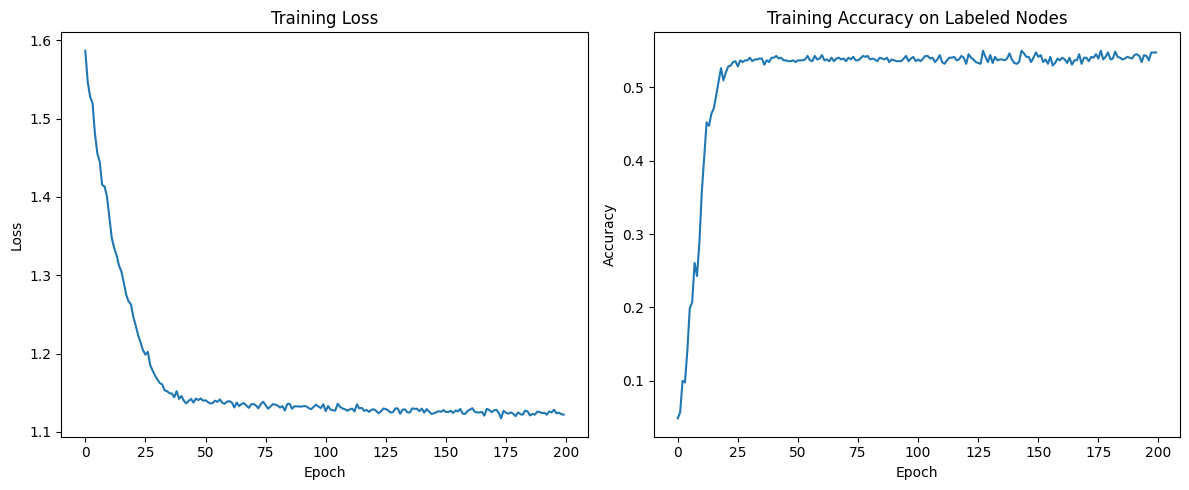

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')

plt.subplot(1, 2, 2)
plt.plot(accuracies)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy on Labeled Nodes')
plt.tight_layout()

In [ ]:
final_pred = best_pred.cpu().numpy()

In [ ]:
print(f'Best model accuracy on labeled nodes: {best_accuracy:.4f}')

Best model accuracy on labeled nodes: 0.5500


In [ ]:
all_predictions = np.bincount(final_pred, minlength=num_classes)
print("\nPredicted label distribution:")
for i, count in enumerate(all_predictions):
    print(f"Class {i} ({label_encoder.classes_[i]}): {count:,} nodes ({count/len(final_pred)*100:.2f}%)")

# Check which classes originally labeled nodes belong to
y_cpu = data.y.cpu() if hasattr(data.y, 'cpu') else data.y
original_class_counts = np.bincount(y_cpu[train_mask].numpy(), minlength=num_classes)
print("\nOriginal labeled node distribution:")
for i, count in enumerate(original_class_counts):
    if count > 0:  # Only show classes that have labeled examples
        print(f"Class {i} ({label_encoder.classes_[i]}): {count:,} nodes ({count/train_mask.sum().item()*100:.2f}%)")

# Compare predictions with original labels
correct_labels = y_cpu[train_mask].numpy()
predicted_labels = final_pred[train_mask] if isinstance(train_mask, torch.Tensor) else final_pred[train_idx]


Predicted label distribution:
Class 0 (Cyborg): 515 nodes (0.16%)
Class 1 (Human): 322,774 nodes (99.22%)
Class 2 (Spam Bot): 0 nodes (0.00%)
Class 3 (Troll): 2,031 nodes (0.62%)

Original labeled node distribution:
Class 0 (Cyborg): 156 nodes (18.57%)
Class 1 (Human): 452 nodes (53.81%)
Class 2 (Spam Bot): 26 nodes (3.10%)
Class 3 (Troll): 206 nodes (24.52%)



Classification Report on Labeled Nodes:
              precision    recall  f1-score   support

      Cyborg       0.60      0.04      0.07       156
       Human       0.55      0.99      0.71       452
    Spam Bot       0.00      0.00      0.00        26
       Troll       0.50      0.04      0.07       206

    accuracy                           0.55       840
   macro avg       0.41      0.27      0.21       840
weighted avg       0.53      0.55      0.41       840


Confusion Matrix:
[[  6 146   0   4]
 [  1 448   0   3]
 [  2  23   0   1]
 [  1 197   0   8]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion matrix saved as 'confusion_matrix.png'


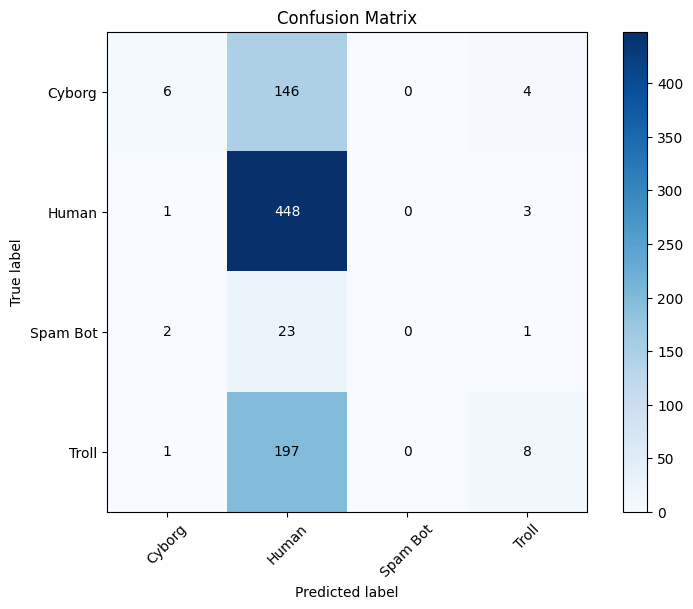

In [ ]:
try:
    from sklearn.metrics import classification_report, confusion_matrix

    print("\nClassification Report on Labeled Nodes:")
    print(classification_report(
        correct_labels,
        predicted_labels,
        target_names=label_encoder.classes_
    ))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(correct_labels, predicted_labels)
    print(cm)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(label_encoder.classes_))
    plt.xticks(tick_marks, label_encoder.classes_, rotation=45)
    plt.yticks(tick_marks, label_encoder.classes_)

    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig('confusion_matrix.png')
    print("Confusion matrix saved as 'confusion_matrix.png'")

except ImportError:
    print("sklearn not available for classification report")

In [ ]:
# Clean up memory
# del model
# if 'out' in locals(): del out
# gc.collect()
# torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("\nPropagation complete! All nodes now have predicted labels.")
print(f"Total processing time: {time.time() - start_time:.2f} seconds")


Propagation complete! All nodes now have predicted labels.
Total processing time: 1670.51 seconds


In [ ]:
print("\nSaving predictions back to graph...")
for i, pred_label in enumerate(final_pred):
    g.vs[i]["predicted_label"] = label_encoder.classes_[pred_label]

# Save the updated graph
output_path = "graph_with_predictions.graphml"
g.write_graphml(output_path)
print(f"Updated graph saved to {output_path}")